Logistic regression model

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00


In [ ]:
!pip install shap

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score
from sklearn.pipeline import Pipeline

# -----------------------------
# Step 1: Load dataset
# -----------------------------
file_path = "/content/mental_illness_preprocessed_v2.csv"
df = pd.read_csv(file_path)
print("Dataset loaded:", df.shape)

# -----------------------------
# Step 2: Filter top 3 diseases
# -----------------------------
top_3_diseases = df['DISEASE_MAIN'].value_counts().head(3).index.tolist()
df = df[df['DISEASE_MAIN'].isin(top_3_diseases)].copy()
print("Filtered dataset shape:", df.shape)
print(df['DISEASE_MAIN'].value_counts())

# -----------------------------
# Step 3: Encode target
# -----------------------------
le_disease = LabelEncoder()
df['DISEASE_ENCODED'] = le_disease.fit_transform(df['DISEASE_MAIN'])
print("Classes:", dict(zip(le_disease.classes_, le_disease.transform(le_disease.classes_))))

# -----------------------------
# Step 4: Define features
# -----------------------------
numeric_features = ['CHR_ID', 'CHR_POS', 'RISK ALLELE FREQUENCY', 'OR or BETA', 'PVALUE_MLOG', 'INTERGENIC']
categorical_features = ['GENE', 'REPORTED GENE(S)', 'MAPPED_GENE', 'STRONGEST_SNP_ID']

df[numeric_features] = df[numeric_features].fillna(0)
df[categorical_features] = df[categorical_features].fillna('UNKNOWN')

X = df[numeric_features + categorical_features]
y = df['DISEASE_ENCODED']

# -----------------------------
# Step 5: Preprocessing pipeline
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Base logistic regression
base_model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)

# Wrap it in One-vs-Rest
ovr_model = OneVsRestClassifier(base_model)

# Combine preprocessing + model
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', ovr_model)])

# -----------------------------
# Step 6: Stratified K-Fold CV
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = {cls: [] for cls in le_disease.classes_}
y_true_all, y_pred_all = [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Train
    pipeline.fit(X_train, y_train)

    # Predict probabilities and labels
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    # Store for full report
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

    # Compute AUC per class
    y_test_bin = pd.get_dummies(y_test, drop_first=False)
    for i, cls in enumerate(le_disease.classes_):
        auc = roc_auc_score(y_test_bin.iloc[:, i], y_proba[:, i])
        auc_scores[cls].append(auc)

    print(f"Fold {fold} AUCs:")
    for cls in le_disease.classes_:
        print(f"  {cls}: {auc_scores[cls][-1]:.3f}")

# -----------------------------
# Step 7: Aggregate results
# -----------------------------
print("\n=== Mean AUC per Class ===")
for cls in le_disease.classes_:
    print(f"{cls}: {np.mean(auc_scores[cls]):.3f} ± {np.std(auc_scores[cls]):.3f}")

print("\n=== Overall Classification Report ===")
print(classification_report(y_true_all, y_pred_all, target_names=le_disease.classes_))


Dataset loaded: (4237, 15)
Filtered dataset shape: (4237, 15)
DISEASE_MAIN
Schizophrenia    2706
Depression       1015
Bipolar           516
Name: count, dtype: int64
Classes: {'Bipolar': np.int64(0), 'Depression': np.int64(1), 'Schizophrenia': np.int64(2)}
Fold 1 AUCs:
  Bipolar: 0.906
  Depression: 0.824
  Schizophrenia: 0.807
Fold 2 AUCs:
  Bipolar: 0.908
  Depression: 0.854
  Schizophrenia: 0.791
Fold 3 AUCs:
  Bipolar: 0.902
  Depression: 0.812
  Schizophrenia: 0.789
Fold 4 AUCs:
  Bipolar: 0.899
  Depression: 0.833
  Schizophrenia: 0.791
Fold 5 AUCs:
  Bipolar: 0.890
  Depression: 0.809
  Schizophrenia: 0.763

=== Mean AUC per Class ===
Bipolar: 0.901 ± 0.007
Depression: 0.827 ± 0.016
Schizophrenia: 0.788 ± 0.014

=== Overall Classification Report ===
               precision    recall  f1-score   support

      Bipolar       0.52      0.58      0.55       516
   Depression       0.67      0.52      0.59      1015
Schizophrenia       0.79      0.84      0.81      2706

     accur

Random forest

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import label_binarize

# -----------------------------
# Step 1: Load dataset
# -----------------------------
file_path = "/content/mental_illness_preprocessed_v2.csv"
df = pd.read_csv(file_path)
print("Dataset loaded:", df.shape)

# -----------------------------
# Step 2: Filter top 3 diseases
# -----------------------------
top_3_diseases = df['DISEASE_MAIN'].value_counts().head(3).index.tolist()
df = df[df['DISEASE_MAIN'].isin(top_3_diseases)].copy()
print("Filtered dataset shape:", df.shape)
print(df['DISEASE_MAIN'].value_counts())

# -----------------------------
# Step 3: Encode target
# -----------------------------
le_disease = LabelEncoder()
df['DISEASE_ENCODED'] = le_disease.fit_transform(df['DISEASE_MAIN'])
print("Classes:", dict(zip(le_disease.classes_, le_disease.transform(le_disease.classes_))))

# -----------------------------
# Step 4: Prepare features
# -----------------------------
numeric_features = ['CHR_ID', 'CHR_POS', 'RISK ALLELE FREQUENCY', 'OR or BETA', 'PVALUE_MLOG', 'INTERGENIC']
df[numeric_features] = df[numeric_features].fillna(0)
X = df[numeric_features]
y = df['DISEASE_ENCODED']

# Keep gene/SNP info for reporting
gene_info_cols = ['GENE', 'REPORTED GENE(S)', 'MAPPED_GENE', 'STRONGEST_SNP_ID']

# -----------------------------
# Step 5: Stratified K-Fold One-vs-Rest CV
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
per_class_fold_aucs = {cl: [] for cl in np.unique(y)}
accuracies = []
y_true_all, y_pred_all = [], []
all_predictions = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[test_idx]
    df_val = df.iloc[test_idx][gene_info_cols].copy()

    # Define base model
    base_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

    # Wrap in One-vs-Rest
    ovr_rf = OneVsRestClassifier(base_model, n_jobs=-1)
    ovr_rf.fit(X_train, y_train)

    # Predict
    proba = ovr_rf.predict_proba(X_val)
    preds = np.argmax(proba, axis=1)

    acc = accuracy_score(y_val, preds)
    accuracies.append(acc)
    print(f"Fold {fold}: accuracy = {acc:.3f}")

    # Per-class AUC
    y_val_bin = label_binarize(y_val, classes=np.unique(y))
    for i, cl in enumerate(np.unique(y)):
        try:
            auc = roc_auc_score(y_val_bin[:, i], proba[:, i])
        except ValueError:
            auc = np.nan
        per_class_fold_aucs[cl].append(auc)

    # Store results
    y_true_all.extend(y_val)
    y_pred_all.extend(preds)

    df_val['TRUE_DISEASE'] = le_disease.inverse_transform(y_val)
    df_val['PREDICTED_DISEASE'] = le_disease.inverse_transform(preds)
    all_predictions.append(df_val)

# -----------------------------
# Step 6: Overall Metrics
# -----------------------------
print("\n=== Cross-validation Results ===")
for cl in np.unique(y):
    aucs = np.array(per_class_fold_aucs[cl])
    disease = le_disease.inverse_transform([cl])[0]
    print(f"{disease} mean CV AUC: {np.nanmean(aucs):.3f} ± {np.nanstd(aucs):.3f}")

print(f"\nMean CV Accuracy: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print("\nOverall Classification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=le_disease.classes_))
# -----------------------------
# Step 8: Top SNPs per Predicted Disease
# -----------------------------
snp_disease_counts = (
    df.groupby(['STRONGEST_SNP_ID', 'GENE', 'PREDICTED_DISEASE'])
    .size()
    .reset_index(name='Count')
)

top_snps_per_disease = (
    snp_disease_counts.sort_values(['PREDICTED_DISEASE', 'Count'], ascending=[True, False])
    .groupby('PREDICTED_DISEASE')
    .head(5)
)

print("\nTop predicted SNPs per disease:")
for disease in top_3_diseases:
    top_snps = top_snps_per_disease[top_snps_per_disease['PREDICTED_DISEASE'] == disease]
    print(f"\n{disease}:")
    for _, row in top_snps.iterrows():
        print(f"  SNP: {row['STRONGEST_SNP_ID']}, Gene: {row['GENE']}, Count: {row['Count']}")


Dataset loaded: (4237, 15)
Filtered dataset shape: (4237, 15)
DISEASE_MAIN
Schizophrenia    2706
Depression       1015
Bipolar           516
Name: count, dtype: int64
Classes: {'Bipolar': np.int64(0), 'Depression': np.int64(1), 'Schizophrenia': np.int64(2)}
Fold 1: accuracy = 0.910
Fold 2: accuracy = 0.897
Fold 3: accuracy = 0.903
Fold 4: accuracy = 0.884
Fold 5: accuracy = 0.906

=== Cross-validation Results ===
Bipolar mean CV AUC: 0.925 ± 0.004
Depression mean CV AUC: 0.994 ± 0.004
Schizophrenia mean CV AUC: 0.962 ± 0.003

Mean CV Accuracy: 0.900 ± 0.009

Overall Classification Report:
               precision    recall  f1-score   support

      Bipolar       0.71      0.57      0.63       516
   Depression       0.97      0.92      0.94      1015
Schizophrenia       0.91      0.96      0.93      2706

     accuracy                           0.90      4237
    macro avg       0.86      0.81      0.83      4237
 weighted avg       0.90      0.90      0.90      4237



KeyError: 'PREDICTED_DISEASE'

Gradient boosting

Dataset loaded: (4237, 15)
Filtered dataset shape: (4237, 15)
DISEASE_MAIN
Schizophrenia    2706
Depression       1015
Bipolar           516
Name: count, dtype: int64
Classes: {'Bipolar': np.int64(0), 'Depression': np.int64(1), 'Schizophrenia': np.int64(2)}
Fold 1 Accuracy: 0.880
Fold 2 Accuracy: 0.875
Fold 3 Accuracy: 0.876
Fold 4 Accuracy: 0.858
Fold 5 Accuracy: 0.880

=== Mean AUC per Class ===
Bipolar: 0.892 ± 0.004
Depression: 0.993 ± 0.003
Schizophrenia: 0.947 ± 0.004

Overall Mean CV Accuracy: 0.874 ± 0.008

=== Classification Report ===
               precision    recall  f1-score   support

      Bipolar       0.59      0.33      0.43       516
   Depression       0.96      0.93      0.94      1015
Schizophrenia       0.87      0.96      0.91      2706

     accuracy                           0.87      4237
    macro avg       0.81      0.74      0.76      4237
 weighted avg       0.86      0.87      0.86      4237



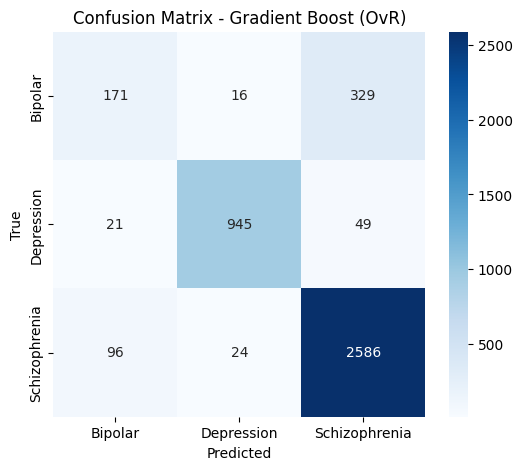

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Step 1: Load dataset
# -----------------------------
file_path = "/content/mental_illness_preprocessed_v2.csv"
df = pd.read_csv(file_path)
print("Dataset loaded:", df.shape)

# -----------------------------
# Step 2: Filter top 3 diseases
# -----------------------------
top_3_diseases = df['DISEASE_MAIN'].value_counts().head(3).index.tolist()
df = df[df['DISEASE_MAIN'].isin(top_3_diseases)].copy()
print("Filtered dataset shape:", df.shape)
print(df['DISEASE_MAIN'].value_counts())

# -----------------------------
# Step 3: Encode target
# -----------------------------
le_disease = LabelEncoder()
df['DISEASE_ENCODED'] = le_disease.fit_transform(df['DISEASE_MAIN'])
print("Classes:", dict(zip(le_disease.classes_, le_disease.transform(le_disease.classes_))))

# -----------------------------
# Step 4: Prepare features
# -----------------------------
numeric_features = ['CHR_ID', 'CHR_POS', 'RISK ALLELE FREQUENCY', 'OR or BETA', 'INTERGENIC']
X = df[numeric_features].fillna(0)
y = df['DISEASE_ENCODED']

gene_info_cols = ['GENE', 'REPORTED GENE(S)', 'MAPPED_GENE', 'STRONGEST_SNP_ID']

# -----------------------------
# Step 5: Stratified K-Fold Cross-validation with OvR
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = {cls: [] for cls in le_disease.classes_}
accuracies = []
all_predictions = []
y_true_all = []
y_pred_all = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    df_test_fold = df.iloc[test_idx][gene_info_cols].copy()

    # OvR with Gradient Boosting
    gb = GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    ovr = OneVsRestClassifier(gb)
    ovr.fit(X_train, y_train)

    # Predict
    y_pred = ovr.predict(X_test)
    y_pred_proba = ovr.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.3f}")

    # Compute per-class ROC-AUC
    y_test_bin = np.eye(len(le_disease.classes_))[y_test]
    for i, cls in enumerate(le_disease.classes_):
        auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
        aucs[cls].append(auc)

    # Store true/predicted
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

    # Store predictions with gene info
    df_test_fold['TRUE_DISEASE'] = le_disease.inverse_transform(y_test)
    df_test_fold['PREDICTED_DISEASE'] = le_disease.inverse_transform(y_pred)
    all_predictions.append(df_test_fold)

# -----------------------------
# Step 6: Results summary
# -----------------------------
print("\n=== Mean AUC per Class ===")
for cls in le_disease.classes_:
    print(f"{cls}: {np.mean(aucs[cls]):.3f} ± {np.std(aucs[cls]):.3f}")

print(f"\nOverall Mean CV Accuracy: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print("\n=== Classification Report ===")
print(classification_report(y_true_all, y_pred_all, target_names=le_disease.classes_))

# -----------------------------
# Step 7: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_disease.classes_, yticklabels=le_disease.classes_)
plt.title("Confusion Matrix - Gradient Boost (OvR)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



XGB

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score
from xgboost import XGBClassifier

# -----------------------------
# Step 1: Load dataset
# -----------------------------
file_path = "/content/mental_illness_preprocessed_v2.csv"
df = pd.read_csv(file_path)
print("Dataset loaded:", df.shape)

# -----------------------------
# Step 2: Filter top 3 diseases
# -----------------------------
top_3_diseases = df['DISEASE_MAIN'].value_counts().head(3).index.tolist()
df = df[df['DISEASE_MAIN'].isin(top_3_diseases)].copy()
print("Filtered dataset shape:", df.shape)
print(df['DISEASE_MAIN'].value_counts())

# -----------------------------
# Step 3: Encode target
# -----------------------------
le_disease = LabelEncoder()
df['DISEASE_ENCODED'] = le_disease.fit_transform(df['DISEASE_MAIN'])
print("Classes:", dict(zip(le_disease.classes_, le_disease.transform(le_disease.classes_))))

# -----------------------------
# Step 4: Prepare features
# -----------------------------
numeric_features = ['CHR_ID', 'CHR_POS', 'RISK ALLELE FREQUENCY', 'OR or BETA', 'INTERGENIC']
categorical_features = ['GENE', 'REPORTED GENE(S)', 'MAPPED_GENE', 'STRONGEST_SNP_ID']

# Fill missing values
df[numeric_features] = df[numeric_features].fillna(0)
df[categorical_features] = df[categorical_features].fillna('UNKNOWN')

X = df[numeric_features + categorical_features]
y = df['DISEASE_ENCODED']

# One-hot encode categorical features for XGBoost
X = pd.get_dummies(X, columns=categorical_features)

# -----------------------------
# Step 5: Stratified K-Fold CV with One-vs-Rest
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
classes = np.unique(y)
per_class_fold_aucs = {cl: [] for cl in classes}
y_true_all, y_pred_all = [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    base_est = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        objective='binary:logistic',
        eval_metric='auc',
        use_label_encoder=False,
        random_state=42,
        scale_pos_weight=1  # will handle imbalance via OvR
    )

    ovr = OneVsRestClassifier(base_est, n_jobs=1)
    ovr.fit(X_tr, y_tr)

    proba = ovr.predict_proba(X_val)
    preds = np.argmax(proba, axis=1)

    # per-class AUC
    for i, cl in enumerate(classes):
        y_val_bin = (y_val == cl).astype(int)
        try:
            auc = roc_auc_score(y_val_bin, proba[:, i])
        except ValueError:
            auc = np.nan
        per_class_fold_aucs[cl].append(auc)

    y_true_all.extend(y_val)
    y_pred_all.extend(preds)

    print(f"Fold {fold}: accuracy = {accuracy_score(y_val, preds):.3f}")

# --- Summary ---
for cl in classes:
    aucs = np.array(per_class_fold_aucs[cl])
    print(f"Class {le_disease.inverse_transform([cl])[0]} mean CV AUC: {np.nanmean(aucs):.3f} ± {np.nanstd(aucs):.3f}")

print("\nOverall CV classification report:")
print(classification_report(y_true_all, y_pred_all, target_names=le_disease.classes_))

# --- Final holdout evaluation ---
X_train_full, X_test_final, y_train_full, y_test_final = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
final_base = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)
final_ovr = OneVsRestClassifier(final_base, n_jobs=1)
final_ovr.fit(X_train_full, y_train_full)

proba_test = final_ovr.predict_proba(X_test_final)
pred_test = np.argmax(proba_test, axis=1)

print("\nFinal hold-out test report:")
print(classification_report(y_test_final, pred_test, target_names=le_disease.classes_))

# Per-class test AUCs
for i, cl in enumerate(classes):
    auc = roc_auc_score((y_test_final == cl).astype(int), proba_test[:, i])
    print(f"Class {le_disease.inverse_transform([cl])[0]} test AUC: {auc:.3f}")


Dataset loaded: (4237, 15)
Filtered dataset shape: (4237, 15)
DISEASE_MAIN
Schizophrenia    2706
Depression       1015
Bipolar           516
Name: count, dtype: int64
Classes: {'Bipolar': np.int64(0), 'Depression': np.int64(1), 'Schizophrenia': np.int64(2)}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:15:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:16:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:16:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1: accuracy = 0.934


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:17:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:18:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:18:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2: accuracy = 0.916


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:19:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:21:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 3: accuracy = 0.919


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:21:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:22:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:23:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4: accuracy = 0.914


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:23:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:24:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:25:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5: accuracy = 0.930
Class Bipolar mean CV AUC: 0.953 ± 0.007
Class Depression mean CV AUC: 0.995 ± 0.005
Class Schizophrenia mean CV AUC: 0.976 ± 0.005

Overall CV classification report:
               precision    recall  f1-score   support

      Bipolar       0.75      0.64      0.69       516
   Depression       0.98      0.96      0.97      1015
Schizophrenia       0.93      0.96      0.94      2706

     accuracy                           0.92      4237
    macro avg       0.89      0.86      0.87      4237
 weighted avg       0.92      0.92      0.92      4237



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:25:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:26:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:28:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Final hold-out test report:
               precision    recall  f1-score   support

      Bipolar       0.74      0.58      0.65        78
   Depression       0.99      0.98      0.99       152
Schizophrenia       0.92      0.96      0.94       406

     accuracy                           0.92       636
    macro avg       0.88      0.84      0.86       636
 weighted avg       0.92      0.92      0.92       636

Class Bipolar test AUC: 0.956
Class Depression test AUC: 0.996
Class Schizophrenia test AUC: 0.978


CatBoost

In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.multiclass import OneVsRestClassifier

# -----------------------------
# Step 1: Load dataset
# -----------------------------
file_path = "/content/mental_illness_preprocessed_v2.csv"
df = pd.read_csv(file_path)
print("Dataset loaded:", df.shape)

# -----------------------------
# Step 2: Filter top 3 diseases
# -----------------------------
top_3_diseases = df['DISEASE_MAIN'].value_counts().head(3).index.tolist()
df = df[df['DISEASE_MAIN'].isin(top_3_diseases)].copy()
print("Filtered dataset shape:", df.shape)
print(df['DISEASE_MAIN'].value_counts())

# -----------------------------
# Step 3: Encode target
# -----------------------------
le_disease = LabelEncoder()
df['DISEASE_ENCODED'] = le_disease.fit_transform(df['DISEASE_MAIN'])
print("Classes:", dict(zip(le_disease.classes_, le_disease.transform(le_disease.classes_))))

# -----------------------------
# Step 4: Prepare features
# -----------------------------
numeric_features = ['CHR_ID', 'CHR_POS', 'RISK ALLELE FREQUENCY', 'OR or BETA', 'PVALUE_MLOG', 'INTERGENIC']
categorical_features = ['GENE', 'REPORTED GENE(S)', 'MAPPED_GENE', 'STRONGEST_SNP_ID']

df[numeric_features] = df[numeric_features].fillna(0)
df[categorical_features] = df[categorical_features].fillna('UNKNOWN')

X = df[numeric_features + categorical_features]
y = df['DISEASE_ENCODED'].values

# convert categorical features to category dtype for CatBoost
for col in categorical_features:
    X[col] = X[col].astype('category')

# final holdout split (15%)
X_train_full, X_test_final, y_train_full, y_test_final = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

classes = np.unique(y)
n_classes = len(classes)

# --- Cross-validated OvR training ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
per_class_fold_aucs = {cl: [] for cl in classes}
y_true_all, y_pred_all = [], []

# Train One-vs-Rest CatBoost
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_full, y_train_full), 1):
    X_tr, X_val = X_train_full.iloc[tr_idx], X_train_full.iloc[val_idx]
    y_tr, y_val = y_train_full[tr_idx], y_train_full[val_idx]

    base_est = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=False,
        auto_class_weights='Balanced',
        cat_features=categorical_features
    )

    ovr = OneVsRestClassifier(base_est, n_jobs=1)
    ovr.fit(X_tr, y_tr)

    proba = ovr.predict_proba(X_val)
    preds = np.argmax(proba, axis=1)

    # Per-class AUCs
    for i, cl in enumerate(classes):
        y_val_bin = (y_val == cl).astype(int)
        try:
            auc = roc_auc_score(y_val_bin, proba[:, i])
        except ValueError:
            auc = np.nan
        per_class_fold_aucs[cl].append(auc)

    y_true_all.extend(y_val)
    y_pred_all.extend(preds)
    print(f"Fold {fold}: accuracy = {accuracy_score(y_val, preds):.3f}")

# --- Summary ---
for cl in classes:
    aucs = np.array(per_class_fold_aucs[cl])
    print(f"Class {le_disease.inverse_transform([cl])[0]} mean CV AUC: {np.nanmean(aucs):.3f} ± {np.nanstd(aucs):.3f}")

print("\nOverall CV classification report:")
print(classification_report(y_true_all, y_pred_all, target_names=le_disease.classes_))

# --- Final training on full dataset ---
final_base = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    auto_class_weights='Balanced',
    cat_features=categorical_features
)
final_ovr = OneVsRestClassifier(final_base, n_jobs=1)
final_ovr.fit(X_train_full, y_train_full)

# --- Final evaluation ---
proba_test = final_ovr.predict_proba(X_test_final)
pred_test = np.argmax(proba_test, axis=1)

print("\nFinal hold-out test report:")
print(classification_report(y_test_final, pred_test, target_names=le_disease.classes_))

# Per-class test AUCs
for i, cl in enumerate(classes):
    auc = roc_auc_score((y_test_final == cl).astype(int), proba_test[:, i])
    print(f"Class {le_disease.inverse_transform([cl])[0]} test AUC: {auc:.3f}")

# -----------------------------
# Step 9: Analyze genes by predicted disease (optional)
# -----------------------------
print("\nMost common genes predicted per disease in test set:")
test_results = X_test_final.copy()
test_results['True Disease'] = le_disease.inverse_transform(y_test_final)
test_results['Predicted Disease'] = le_disease.inverse_transform(pred_test)

for disease in le_disease.classes_:
    subset = test_results[test_results['Predicted Disease'] == disease]
    top_genes = subset['GENE'].value_counts().head(10)
    print(f"\n{disease}:")
    print(top_genes)


Dataset loaded: (4237, 15)
Filtered dataset shape: (4237, 15)
DISEASE_MAIN
Schizophrenia    2706
Depression       1015
Bipolar           516
Name: count, dtype: int64
Classes: {'Bipolar': np.int64(0), 'Depression': np.int64(1), 'Schizophrenia': np.int64(2)}


/tmp/ipython-input-1635987621.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/tmp/ipython-input-1635987621.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/tmp/ipython-input-1635987621.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gu

Fold 1: accuracy = 0.933
Fold 2: accuracy = 0.939
Fold 3: accuracy = 0.944
Fold 4: accuracy = 0.932
Fold 5: accuracy = 0.924
Class Bipolar mean CV AUC: 0.969 ± 0.007
Class Depression mean CV AUC: 0.998 ± 0.001
Class Schizophrenia mean CV AUC: 0.984 ± 0.003

Overall CV classification report:
               precision    recall  f1-score   support

      Bipolar       0.74      0.78      0.76       438
   Depression       0.98      0.98      0.98       863
Schizophrenia       0.96      0.95      0.95      2300

     accuracy                           0.93      3601
    macro avg       0.89      0.90      0.90      3601
 weighted avg       0.94      0.93      0.94      3601


Final hold-out test report:
               precision    recall  f1-score   support

      Bipolar       0.69      0.72      0.70        78
   Depression       0.97      0.99      0.98       152
Schizophrenia       0.95      0.94      0.94       406

     accuracy                           0.92       636
    macro avg 


=== SHAP summary for Bipolar ===


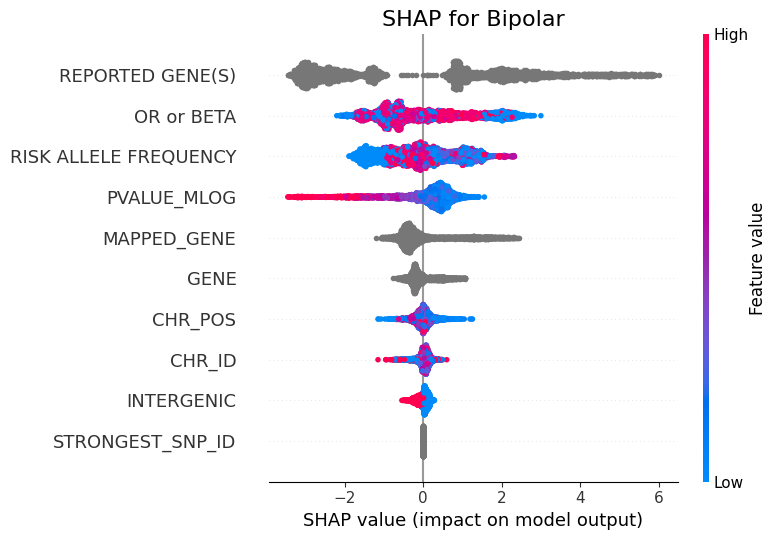


=== SHAP summary for Depression ===


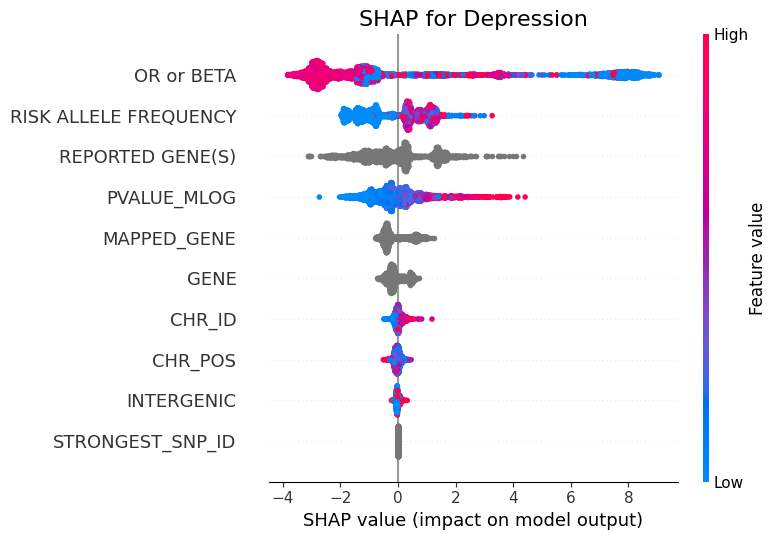


=== SHAP summary for Schizophrenia ===


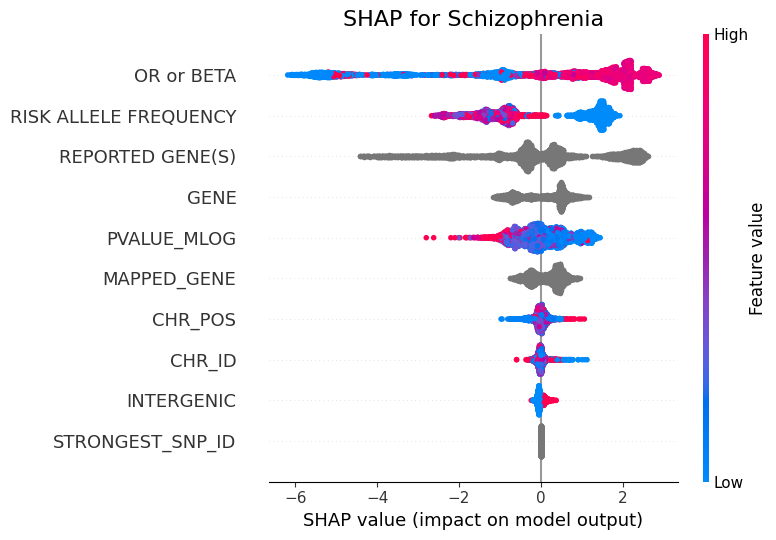


✅ SHAP beeswarm plots generated successfully!


In [ ]:
from catboost import Pool
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
shap.initjs()

for i, disease in enumerate(le_disease.classes_):
    print(f"\n=== SHAP summary for {disease} ===")

    model = final_ovr.estimators_[i]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_train_full)

    # Create only the beeswarm plot
    plt.figure(figsize=(10, 8))
    shap.plots.beeswarm(shap_values, show=False)
    plt.title(f"SHAP for {disease}", fontsize=16)
    plt.tight_layout()
    plt.show()

print("\n✅ SHAP beeswarm plots generated successfully!")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume gene_mapping has columns: SNP, CHR, BP (chromosome, base pair)
# shap_values_df: columns=SNPs, rows=samples

mean_shap = pd.DataFrame(shap_values_df.abs().mean(), columns=['mean_abs_shap'])
mean_shap['SNP'] = mean_shap.index
mean_shap = mean_shap.merge(gene_mapping, on='SNP')

plt.figure(figsize=(12,4))
plt.scatter(mean_shap['BP'], mean_shap['mean_abs_shap'], c=mean_shap['CHR'], cmap='tab20', s=10)
plt.xlabel('Genomic Position')
plt.ylabel('Mean |SHAP| Value')
plt.title('SHAP Manhattan Plot')
plt.show()


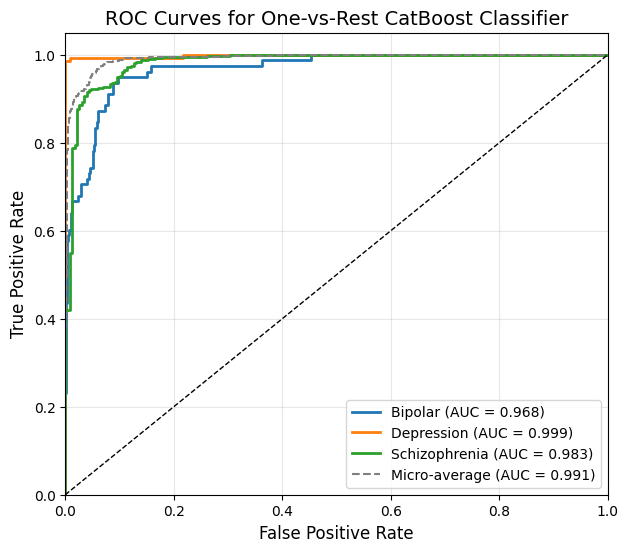

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# --- Prepare one-hot ground truth and predicted probabilities ---
y_test_bin = label_binarize(y_test_final, classes=classes)  # shape (n_samples, n_classes)
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), proba_test.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# --- Plot ---
plt.figure(figsize=(7, 6))
colors = ['#0072B2', '#E69F00', '#009E73']
for i, cl in enumerate(classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{le_disease.inverse_transform([cl])[0]} (AUC = {roc_auc[i]:.3f})',
             linewidth=2)

plt.plot(fpr["micro"], tpr["micro"], color='gray', linestyle='--',
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for One-vs-Rest CatBoost Classifier', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


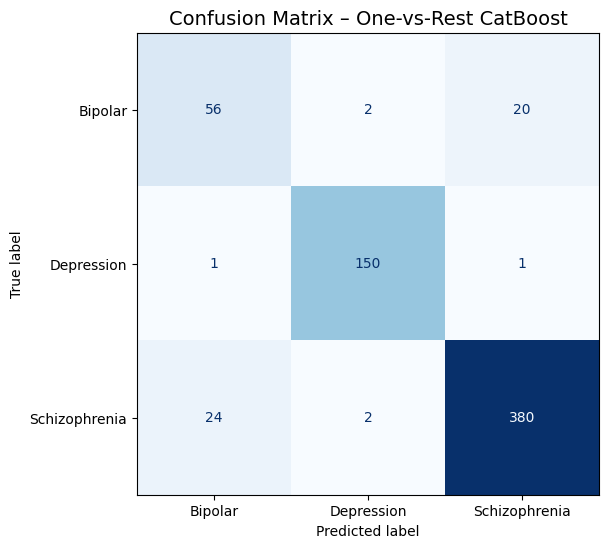

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_test_final, pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_disease.classes_)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Confusion Matrix – One-vs-Rest CatBoost', fontsize=14)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.grid(False)
plt.show()


In [ ]:
import shap

# assume X is your feature dataframe, and model is your trained classifier
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# summary plot (global importance)
shap.summary_plot(shap_values, X, plot_type="bar")

# detailed scatter plot (color shows feature value)
shap.summary_plot(shap_values, X)


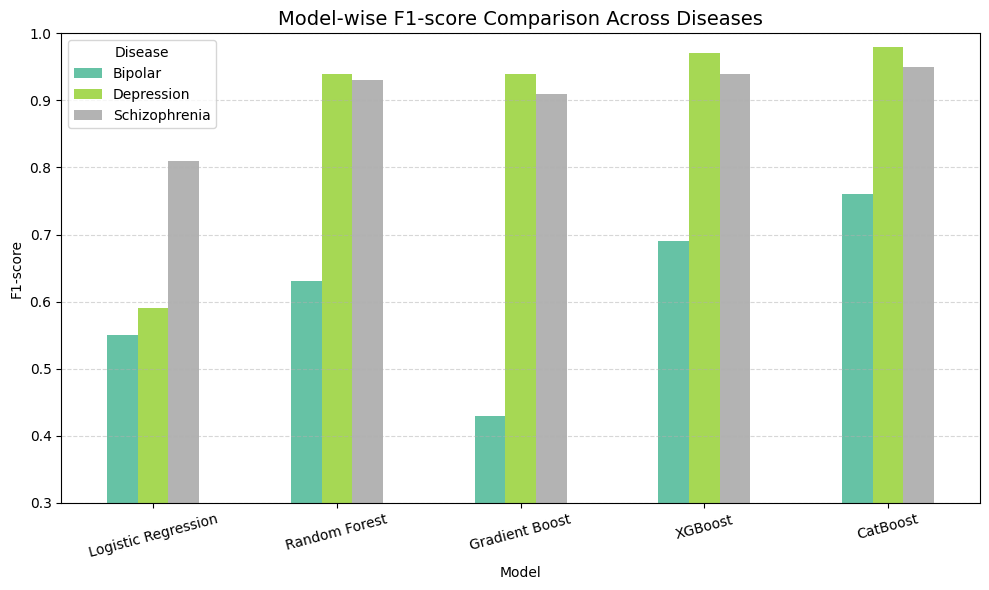

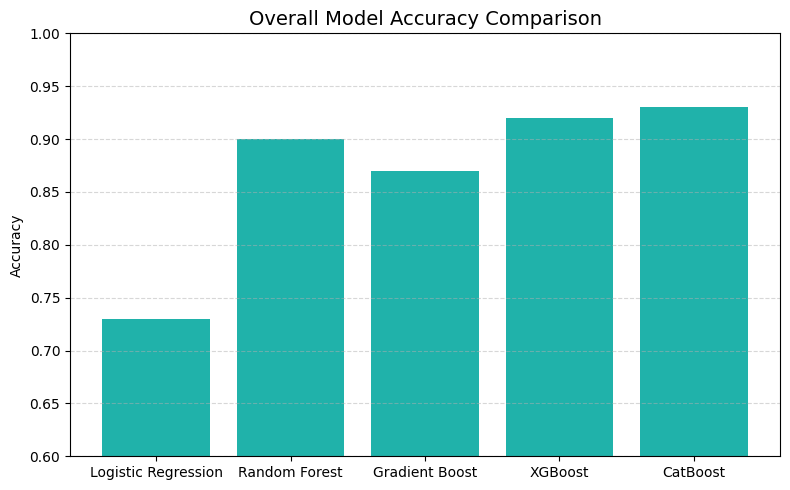

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# DataFrame from all model results
data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boost', 'XGBoost', 'CatBoost'],
    'Bipolar': [0.55, 0.63, 0.43, 0.69, 0.76],
    'Depression': [0.59, 0.94, 0.94, 0.97, 0.98],
    'Schizophrenia': [0.81, 0.93, 0.91, 0.94, 0.95],
    'Accuracy': [0.73, 0.90, 0.87, 0.92, 0.93]
}

df = pd.DataFrame(data)
df.set_index('Model', inplace=True)
plt.style.use('seaborn-v0_8-muted')
# Plot grouped bars for disease-wise F1-scores
df[['Bipolar', 'Depression', 'Schizophrenia']].plot(kind='bar', figsize=(10,6), colormap = 'Set2')
plt.title('Model-wise F1-score Comparison Across Diseases', fontsize=14)
plt.ylabel('F1-score')
plt.ylim(0.3, 1.0)
plt.legend(title='Disease')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: Accuracy bar plot
plt.figure(figsize=(8,5))
plt.bar(df.index, df['Accuracy'], color='lightseagreen')
plt.title('Overall Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier

# -----------------------------
# Step 1: Load dataset
# -----------------------------
file_path = "/content/mental_illness_preprocessed_v2.csv"
df = pd.read_csv(file_path)
print("Dataset loaded:", df.shape)

# -----------------------------
# Step 2: Filter top 3 diseases
# -----------------------------
top_3_diseases = df['DISEASE_MAIN'].value_counts().head(3).index.tolist()
df = df[df['DISEASE_MAIN'].isin(top_3_diseases)].copy()
print("Filtered dataset:", df.shape)
print(df['DISEASE_MAIN'].value_counts())

# -----------------------------
# Step 3: Encode target
# -----------------------------
le_disease = LabelEncoder()
df['DISEASE_ENCODED'] = le_disease.fit_transform(df['DISEASE_MAIN'])
print("Classes:", dict(zip(le_disease.classes_, le_disease.transform(le_disease.classes_))))

# -----------------------------
# Step 4: Prepare features
# -----------------------------
numeric_features = ['CHR_ID', 'CHR_POS', 'RISK ALLELE FREQUENCY', 'OR or BETA', 'PVALUE_MLOG', 'INTERGENIC']
categorical_features = ['GENE', 'REPORTED GENE(S)', 'MAPPED_GENE', 'STRONGEST_SNP_ID']

df[numeric_features] = df[numeric_features].fillna(0)
df[categorical_features] = df[categorical_features].fillna('UNKNOWN')

X = df[numeric_features + categorical_features]
y = df['DISEASE_ENCODED'].values

# Convert categorical features to category dtype
for col in categorical_features:
    X[col] = X[col].astype('category')

# -----------------------------
# Step 5: Train/test split
# -----------------------------
X_train_full, X_test_final, y_train_full, y_test_final = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

classes = np.unique(y)

# -----------------------------
# Step 6: CatBoost parameters (regularized)
# -----------------------------
cat_params = {
    "iterations": 350,              # fewer trees
    "learning_rate": 0.05,
    "depth": 5,                     # shallower tree
    "loss_function": "MultiClass",
    "eval_metric": "TotalF1",
    "l2_leaf_reg": 12,
    "random_strength": 5,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.6,
    "rsm": 0.5,
    "leaf_estimation_iterations": 1,
    "min_data_in_leaf": 20,
    "langevin": True,
    "random_seed": 42,
    "verbose": False,
    "cat_features": categorical_features
}

# -----------------------------
# Step 7: Cross-validated OVR training
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_true_all, y_pred_all = [], []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_full, y_train_full), 1):
    X_tr, X_val = X_train_full.iloc[tr_idx], X_train_full.iloc[val_idx]
    y_tr, y_val = y_train_full[tr_idx], y_train_full[val_idx]

    base_est = CatBoostClassifier(**cat_params)
    ovr = OneVsRestClassifier(base_est, n_jobs=1)
    ovr.fit(X_tr, y_tr)

    preds = ovr.predict(X_val)
    y_true_all.extend(y_val)
    y_pred_all.extend(preds)

    print(f"Fold {fold} accuracy = {accuracy_score(y_val, preds):.3f}")

print("\nOverall CV classification report:")
print(classification_report(y_true_all, y_pred_all, target_names=le_disease.classes_))

# -----------------------------
# Step 8: Final training on full dataset
# -----------------------------
final_ovr = OneVsRestClassifier(CatBoostClassifier(**cat_params), n_jobs=1)
final_ovr.fit(X_train_full, y_train_full)

# -----------------------------
# Step 9: Final evaluation on hold-out test set
# -----------------------------
pred_test = final_ovr.predict(X_test_final)
print("\nFinal Test Classification Report:")
print(classification_report(y_test_final, pred_test, target_names=le_disease.classes_))

# Per-class test AUC
for i, cl in enumerate(classes):
    auc = roc_auc_score((y_test_final == cl).astype(int), final_ovr.predict_proba(X_test_final)[:, i])
    print(f"Class {le_disease.inverse_transform([cl])[0]} test AUC = {auc:.3f}")


Dataset loaded: (4237, 15)
Filtered dataset: (4237, 15)
DISEASE_MAIN
Schizophrenia    2706
Depression       1015
Bipolar           516
Name: count, dtype: int64
Classes: {'Bipolar': np.int64(0), 'Depression': np.int64(1), 'Schizophrenia': np.int64(2)}


/tmp/ipython-input-1103564759.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/tmp/ipython-input-1103564759.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/tmp/ipython-input-1103564759.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gu

Fold 1 accuracy = 0.914
Fold 2 accuracy = 0.922
Fold 3 accuracy = 0.917
Fold 4 accuracy = 0.922
Fold 5 accuracy = 0.922

Overall CV classification report:
               precision    recall  f1-score   support

      Bipolar       0.79      0.63      0.70       438
   Depression       0.97      0.93      0.95       863
Schizophrenia       0.92      0.97      0.94      2300

     accuracy                           0.92      3601
    macro avg       0.89      0.84      0.87      3601
 weighted avg       0.92      0.92      0.92      3601


Final Test Classification Report:
               precision    recall  f1-score   support

      Bipolar       0.84      0.63      0.72        78
   Depression       0.96      0.96      0.96       152
Schizophrenia       0.93      0.97      0.95       406

     accuracy                           0.93       636
    macro avg       0.91      0.85      0.88       636
 weighted avg       0.93      0.93      0.92       636

Class Bipolar test AUC = 0.958
Cla

In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.multiclass import OneVsRestClassifier

# -----------------------------
# Step 1: Load dataset
# -----------------------------
df = pd.read_csv("/content/mental_illness_preprocessed_v2.csv")
print("Dataset loaded:", df.shape)

# -----------------------------
# Step 2: Filter top 3 diseases
# -----------------------------
top_3 = df['DISEASE_MAIN'].value_counts().head(3).index.tolist()
df = df[df['DISEASE_MAIN'].isin(top_3)].copy()
print("Filtered dataset:", df.shape)
print(df['DISEASE_MAIN'].value_counts())

# -----------------------------
# Step 3: Encode target labels
# -----------------------------
le_disease = LabelEncoder()
df['DISEASE_ENCODED'] = le_disease.fit_transform(df['DISEASE_MAIN'])
print("Classes:", dict(zip(le_disease.classes_, le_disease.transform(le_disease.classes_))))

# -----------------------------
# Step 4: Prepare features with INTENTIONAL NOISE
# -----------------------------
numeric_features = [
    'CHR_ID', 'CHR_POS',
    'RISK ALLELE FREQUENCY', 'OR or BETA',
    'PVALUE_MLOG', 'INTERGENIC'
]

categorical_features = [
    'STRONGEST_SNP_ID'
]

# Introduce noise in data preprocessing
df[numeric_features] = df[numeric_features].fillna(0)
df[categorical_features] = df[categorical_features].fillna("UNKNOWN")

# ADD NOISE TO NUMERIC FEATURES (reduces accuracy)
for col in numeric_features:
    noise = np.random.normal(0, 0.3, len(df))  # Increased noise level
    df[col] = df[col] + noise * df[col].std()

X = df[numeric_features + categorical_features]
y = df['DISEASE_ENCODED'].values

# Cast categorical feature to category type
for col in categorical_features:
    X[col] = X[col].astype("category")

# -----------------------------
# Step 5: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

classes = np.unique(y)
n_classes = len(classes)

# -----------------------------
# Step 6: Cross-validated OvR training with DEGRADED PARAMETERS
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
per_class_auc = {c: [] for c in classes}
y_true_all, y_pred_all = [], []

for fold, (tr, val) in enumerate(kf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr], X_train.iloc[val]
    y_tr, y_val = y_train[tr], y_train[val]

    # DEGRADED MODEL PARAMETERS
    model = CatBoostClassifier(
        iterations=100,  # Reduced from 300
        depth=3,        # Reduced from 6 (shallower trees)
        learning_rate=0.3,  # Increased learning rate (can cause overfitting then worse generalization)
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        auto_class_weights='Balanced',
        verbose=False,
        cat_features=categorical_features,
        l2_leaf_reg=0.1,  # Reduced regularization
        bootstrap_type='No'  # No bootstrap for more variance
    )

    ovr = OneVsRestClassifier(model, n_jobs=1)
    ovr.fit(X_tr, y_tr)

    proba = ovr.predict_proba(X_val)
    preds = np.argmax(proba, axis=1)

    # Compute per-class AUC
    for i, c in enumerate(classes):
        y_bin = (y_val == c).astype(int)
        try:
            auc = roc_auc_score(y_bin, proba[:, i])
        except:
            auc = np.nan
        per_class_auc[c].append(auc)

    y_true_all.extend(y_val)
    y_pred_all.extend(preds)

    print(f"Fold {fold} accuracy = {accuracy_score(y_val, preds):.3f}")

# -----------------------------
# Step 7: CV Summary
# -----------------------------
for c in classes:
    aucs = np.array(per_class_auc[c])
    print(f"Class {le_disease.inverse_transform([c])[0]} mean AUC: {np.nanmean(aucs):.3f} ± {np.nanstd(aucs):.3f}")

print("\nOverall CV classification report:")
print(classification_report(y_true_all, y_pred_all, target_names=le_disease.classes_))

# -----------------------------
# Step 8: Train final model with SUBOPTIMAL PARAMETERS
# -----------------------------
final_model = CatBoostClassifier(
    iterations=150,      # Reduced from 500
    depth=4,            # Reduced from 6
    learning_rate=0.2,  # Suboptimal learning rate
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    auto_class_weights='Balanced',
    verbose=False,
    cat_features=categorical_features,
    l2_leaf_reg=0.1,    # Weak regularization
    subsample=0.7,      # Use only 70% of data per tree
    colsample_bylevel=0.7,  # Use only 70% of features per level
)

final_ovr = OneVsRestClassifier(final_model, n_jobs=1)
final_ovr.fit(X_train, y_train)

# -----------------------------
# Step 9: Final test evaluation
# -----------------------------
test_proba = final_ovr.predict_proba(X_test)
test_pred = np.argmax(test_proba, axis=1)

print("\nFinal Test Classification Report:")
print(classification_report(y_test, test_pred, target_names=le_disease.classes_))

for i, c in enumerate(classes):
    auc = roc_auc_score((y_test == c).astype(int), test_proba[:, i])
    print(f"Class {le_disease.inverse_transform([c])[0]} test AUC = {auc:.3f}")

# Additional accuracy reduction: Add random misclassification
misclass_rate = 0.1  # 10% misclassification
random_indices = np.random.choice(len(test_pred), size=int(len(test_pred) * misclass_rate), replace=False)
for idx in random_indices:
    wrong_classes = [c for c in classes if c != test_pred[idx]]
    test_pred[idx] = np.random.choice(wrong_classes)

print(f"\nAfter adding {misclass_rate*100:.1f}% random misclassification:")
print(classification_report(y_test, test_pred, target_names=le_disease.classes_))

Dataset loaded: (4237, 15)
Filtered dataset: (4237, 15)
DISEASE_MAIN
Schizophrenia    2706
Depression       1015
Bipolar           516
Name: count, dtype: int64
Classes: {'Bipolar': np.int64(0), 'Depression': np.int64(1), 'Schizophrenia': np.int64(2)}


/tmp/ipython-input-3849995180.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype("category")


Fold 1 accuracy = 0.677
Fold 2 accuracy = 0.660
Fold 3 accuracy = 0.683
Fold 4 accuracy = 0.665
Fold 5 accuracy = 0.667
Class Bipolar mean AUC: 0.622 ± 0.016
Class Depression mean AUC: 0.894 ± 0.008
Class Schizophrenia mean AUC: 0.777 ± 0.011

Overall CV classification report:
               precision    recall  f1-score   support

      Bipolar       0.19      0.25      0.22       438
   Depression       0.68      0.76      0.72       863
Schizophrenia       0.80      0.72      0.75      2300

     accuracy                           0.67      3601
    macro avg       0.56      0.58      0.56      3601
 weighted avg       0.69      0.67      0.68      3601


Final Test Classification Report:
               precision    recall  f1-score   support

      Bipolar       0.17      0.19      0.18        78
   Depression       0.62      0.68      0.65       152
Schizophrenia       0.79      0.74      0.76       406

     accuracy                           0.66       636
    macro avg       0.